In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
ani = pd.read_csv("/home/jupyter-haydee/CAMDA/pruebas/ani/campylobacter.csv")  # ← reemplaza con tu archivo real

# Extraer solo el nombre sin ruta ni extensión .fna
#ani.columns = ani.columns.str.extract(r'/([^/]+)\.fa$')[0]
#ani.rename(columns={'/files/camda2024/resistence/genome_reference/genbank/GCA_000009085.1.fna': 'GCA_000009085.1'}, inplace=True)
#ani.columns = ani.columns.str.extract(r'/([^/]+)\.fa?$')[0]
ani.columns = ani.columns.str.replace(r'^.*/', '', regex=True)  # quita ruta si existe
ani.columns = ani.columns.str.replace(r'\.fna?$', '', regex=True)  # quita extensión
ani.columns = ani.columns.str.replace(r'\.fa?$', '', regex=True)  # quita extensión
ani.index = ani.columns

ani

,SRS5500741,SRS9410746,SRS1369906,SRS1315979,ERS11638974,ERS11639024,SRS1503960,ERS11639051,SRS9410797,SRS1332692,...,SRS1272399,SRS1529695,SRS9410810,ERS11638978,ERS11639076,ERS11639126,SRS1277972,ERS11639082,ERS11638888,SRS1332289
SRS5500741,1.000000,0.982695,0.988165,0.987113,0.993976,0.991964,0.989180,0.989031,0.989433,0.995540,...,0.992799,0.994149,0.991987,0.993885,0.995371,0.992805,0.991629,0.988066,0.986984,0.996029
SRS9410746,0.982695,1.000000,0.980564,0.982309,0.982315,0.982067,0.983327,0.981121,0.982261,0.983402,...,0.981261,0.981606,0.982677,0.981785,0.982405,0.984935,0.982176,0.982675,0.977253,0.982986
SRS1369906,0.988165,0.980564,1.000000,0.986100,0.987175,0.987137,0.986704,0.988643,0.988468,0.988218,...,0.986968,0.988477,0.987601,0.986667,0.987806,0.986058,0.987369,0.986892,0.982496,0.988438
SRS1315979,0.987113,0.982309,0.986100,1.000000,0.985475,0.985680,0.993141,0.984134,0.984379,0.987098,...,0.989059,0.988870,0.985849,0.985200,0.986890,0.985274,0.987705,0.985603,0.979943,0.987799
ERS11638974,0.993976,0.982315,0.987175,0.985475,1.000000,0.991050,0.987967,0.989010,0.988840,0.993601,...,0.991175,0.992925,0.991097,0.996873,0.993849,0.996855,0.990579,0.987796,0.986669,0.993327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERS11639126,0.992805,0.984935,0.986058,0.985274,0.996855,0.990417,0.987931,0.987745,0.988128,0.992325,...,0.990664,0.991623,0.989947,0.995383,0.992544,1.000000,0.989261,0.986851,0.984949,0.992047
SRS1277972,0.991629,0.982176,0.987369,0.987705,0.990579,0.992519,0.990674,0.987431,0.987635,0.992046,...,0.992748,0.991080,0.992566,0.989839,0.992546,0.989261,1.000000,0.987119,0.987252,0.991781
ERS11639082,0.988066,0.982675,0.986892,0.985603,0.987796,0.987699,0.987579,0.989066,0.988343,0.988089,...,0.987417,0.987553,0.988215,0.987428,0.987758,0.986851,0.987119,1.000000,0.983179,0.987900
ERS11638888,0.986984,0.977253,0.982496,0.979943,0.986669,0.993113,0.982704,0.983808,0.984165,0.986395,...,0.984354,0.986013,0.993220,0.985716,0.987146,0.984949,0.987252,0.983179,1.000000,0.986094


In [44]:
# 3. Cargar metadatos
df_train = pd.read_csv("data/pangenome_campylobacter_train.csv.bz2")
df_test = pd.read_csv("data/pangenome_campylobacter_test.csv.bz2")
meta = pd.concat([df_train, df_test], ignore_index=True)
meta = meta[meta['biosample'].isin(ani.index)].copy()
meta = meta.set_index('biosample').reindex(ani.index)

In [47]:
# ====================
# ⚙️ Parámetros
# ====================
id_referencia = "GCA_000009085.1"
n_total = 60

# ====================
# 📊 Clasificación ANI
# ====================
ani_vs_ref = ani.loc[id_referencia]

# Separar genomas con ANI < 96 y ≥ 96 (excluyendo al propio ref)
menores_96 = ani_vs_ref[ani_vs_ref < 0.96]
mayores_96 = ani_vs_ref[ani_vs_ref >= 0.96].drop(index=id_referencia, errors="ignore")

# Asegurar que estén en metadatos
menores_96 = menores_96[menores_96.index.isin(meta.index)]
mayores_96 = mayores_96[mayores_96.index.isin(meta.index)]

menores_96

SRS9410790    0.956251
Name: GCA_000009085.1, dtype: float64

In [48]:
# ====================
# ✅ Selección del subconjunto
# ====================

# IDs a incluir
ids_sub = [id_referencia] + menores_96.index.tolist()

# Cuántos faltan para llegar a 100
faltantes = n_total - len(ids_sub)

# Si faltan genomas, tomarlos de los mayores_96 balanceadamente
if faltantes > 0:
    meta_mayores = meta.loc[mayores_96.index].copy()
    meta_mayores["ani"] = mayores_96

    # Selección balanceada (hasta completar los faltantes)
    def seleccionar_balanceado(df, n_total):
        grupos = {
            "Resistant": df[df["assigned_phenotype"] == "Resistant"],
            "Susceptible": df[df["assigned_phenotype"] == "Susceptible"],
            "none": df[df["assigned_phenotype"].isna()]
        }

        n_grupo = n_total // 3
        seleccionados = []

        for key, subdf in grupos.items():
            n = min(n_grupo, len(subdf))
            seleccionados.append(subdf.sample(n, random_state=42))

        # Si aún faltan, completar con lo que haya
        total_seleccionados = pd.concat(seleccionados)
        faltan = n_total - len(total_seleccionados)
        if faltan > 0:
            restantes = df.drop(index=total_seleccionados.index, errors="ignore")
            if len(restantes) > 0:
                extras = restantes.sample(min(faltan, len(restantes)), random_state=42)
                total_seleccionados = pd.concat([total_seleccionados, extras])

        return total_seleccionados

    seleccion_extra = seleccionar_balanceado(meta_mayores, faltantes)
    ids_sub += seleccion_extra.index.tolist()

# Submatriz final
sub_ani = ani.loc[ids_sub, ids_sub]
sub_ani

,GCA_000009085.1,SRS9410790,SRS1424318,SRS1369896,SRS1349929,SRS1446067,SRS1503964,SRS1402345,SRS1327422,SRS1598353,...,SRS1609261,SRS1609251,SRS1446048,ERS11639064,ERS11638989,SRS9410839,SRS1568761,SRS1568752,SRS5500770,SRS1297459
GCA_000009085.1,1.000000,0.956251,0.995724,0.986264,0.992458,0.986207,0.983834,0.986154,0.995650,0.981813,...,0.986158,0.995644,0.987726,0.994727,0.987302,0.984120,0.995796,0.983631,0.988066,0.995831
SRS9410790,0.956251,1.000000,0.957231,0.956164,0.954850,0.956338,0.956875,0.956337,0.957194,0.953999,...,0.956005,0.957246,0.953027,0.956657,0.952655,0.966123,0.957191,0.965461,0.952987,0.955877
SRS1424318,0.995724,0.957231,1.000000,0.986189,0.992599,0.986163,0.983740,0.986492,0.999510,0.982581,...,0.986262,0.999269,0.987283,0.993612,0.987204,0.984558,0.999851,0.984434,0.987785,0.994656
SRS1369896,0.986264,0.956164,0.986189,1.000000,0.986714,0.999390,0.984262,0.998958,0.986196,0.983143,...,0.999479,0.986199,0.984176,0.984936,0.983844,0.984232,0.986208,0.984606,0.983654,0.986948
SRS1349929,0.992458,0.954850,0.992599,0.986714,1.000000,0.986658,0.983777,0.986913,0.992531,0.982191,...,0.987145,0.992513,0.985699,0.990199,0.986394,0.982696,0.992623,0.982654,0.985252,0.992828
SRS1446067,0.986207,0.956338,0.986163,0.999390,0.986658,1.000000,0.984210,0.999140,0.986169,0.983032,...,0.999163,0.986172,0.984486,0.984944,0.983856,0.984181,0.986181,0.984583,0.983635,0.987177
SRS1503964,0.983834,0.956875,0.983740,0.984262,0.983777,0.984210,1.000000,0.984076,0.983928,0.980426,...,0.984250,0.983908,0.980507,0.982305,0.979844,0.985286,0.983788,0.984316,0.980826,0.983587
SRS1402345,0.986154,0.956337,0.986492,0.998958,0.986913,0.999140,0.984076,1.000000,0.986500,0.982906,...,0.998951,0.986502,0.983998,0.985843,0.983751,0.984538,0.986511,0.984633,0.983815,0.986777
SRS1327422,0.995650,0.957194,0.999510,0.986196,0.992531,0.986169,0.983928,0.986500,1.000000,0.982605,...,0.986269,0.999419,0.987293,0.993479,0.987155,0.984465,0.999559,0.984210,0.987770,0.994621
SRS1598353,0.981813,0.953999,0.982581,0.983143,0.982191,0.983032,0.980426,0.982906,0.982605,1.000000,...,0.983447,0.982332,0.981597,0.981167,0.979257,0.981220,0.982627,0.981806,0.979645,0.982124


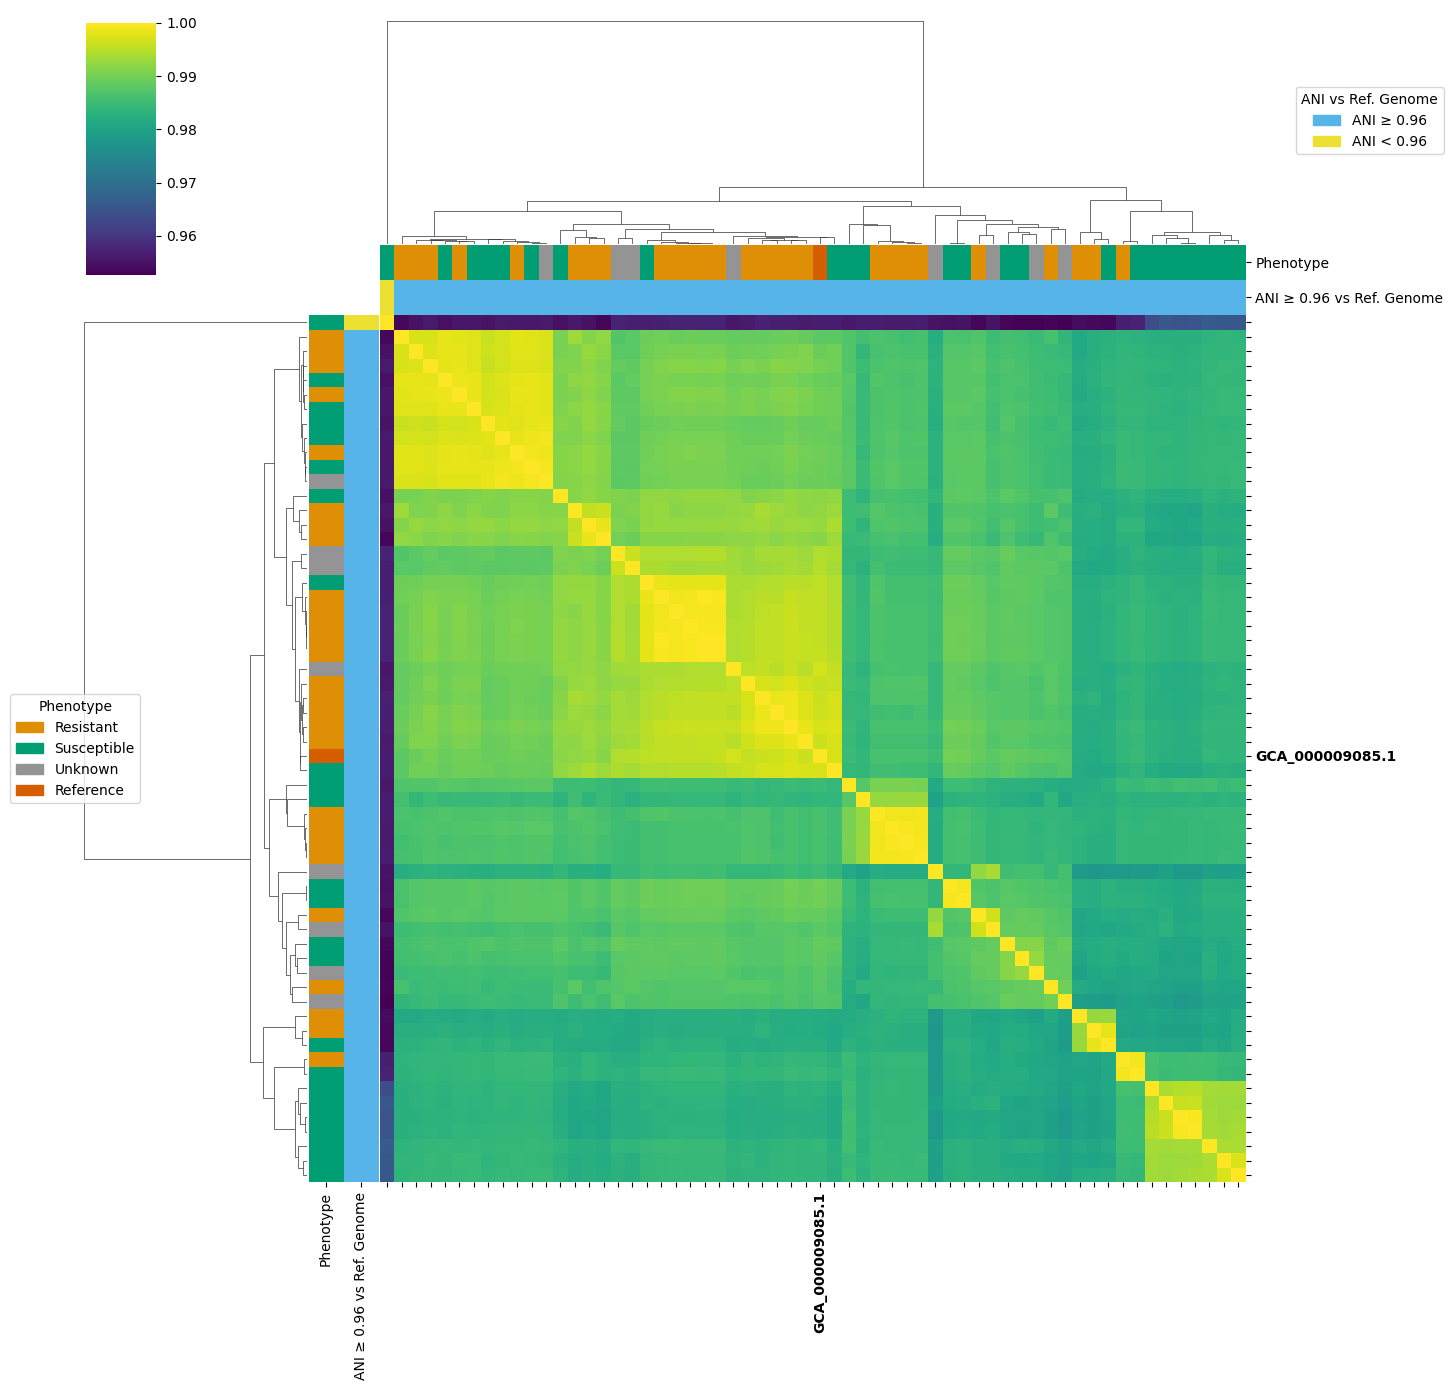

In [57]:
import matplotlib.patches as mpatches
# Barra 1: phenotype (con azul para el ref)
phenotype_colors = meta['assigned_phenotype'].map({
    "Resistant": "#de8f05",
    "Susceptible": "#029e73"
}).fillna("#949494")
phenotype_colors.loc[id_referencia] = "#d55e00"

# Barra 2: ANI ≥ 96 vs ref
ani_color_vector = (ani.loc[id_referencia] >= 0.96).map({
    True: "#56b4e9",
    False: "#ece133"
}).reindex(sub_ani.index)

# Combinar colores
row_colors_df = pd.DataFrame({
    "Phenotype": phenotype_colors.loc[sub_ani.index],
    "ANI ≥ 0.96 vs Ref. Genome": ani_color_vector
}, index=sub_ani.index)

# Plot
g = sns.clustermap(
    sub_ani,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    cmap="viridis",
    figsize=(14, 14),
    xticklabels=True,
    yticklabels=True
)

# Etiquetar solo al genoma de referencia
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() == id_referencia:
        label.set_visible(True)
        label.set_color("black")
        label.set_fontweight("bold")
    else:
        label.set_visible(False)

for label in g.ax_heatmap.get_xticklabels():
    if label.get_text() == id_referencia:
        label.set_visible(True)
        label.set_color("black")
        label.set_fontweight("bold")
        label.set_rotation(90)
    else:
        label.set_visible(False)




# Crear leyendas manualmente
phenotype_patches = [
    mpatches.Patch(color="#de8f05", label="Resistant"),
    mpatches.Patch(color="#029e73", label="Susceptible"),
    mpatches.Patch(color="#949494", label="Unknown"),
    mpatches.Patch(color="#d55e00", label="Reference")
]

ani_patches = [
    mpatches.Patch(color="#56b4e9", label="ANI ≥ 0.96"),
    mpatches.Patch(color="#ece133", label="ANI < 0.96")
]

# Agregar leyendas, en este caso las dos en la misma figura, puedes ajustar posición
g.ax_row_dendrogram.legend(handles=phenotype_patches, title="Phenotype", bbox_to_anchor=(-0.3, 0.5), loc='center left')
g.ax_col_dendrogram.legend(handles=ani_patches, title="ANI vs Ref. Genome", bbox_to_anchor=(1.05, 0.7), loc='upper left')



#g.ax_heatmap.set_title("ANI clustering (balanceado, ref + ANI < 96 + complemento)", fontsize=14)
g.savefig("/home/jupyter-haydee/CAMDA/pruebas/ani/clustermap_balanceado_campylobacter.svg", format="svg")
plt.show()


In [50]:
print(sns.color_palette("colorblind").as_hex())

['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


In [52]:
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]